# Loading Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
sns.set(style="whitegrid")

df=pd.read_csv("data/data_preprocessing.csv")
df.head()

# UNIVARIATE ANALYSIS

## 1. Satisfaction Distribution

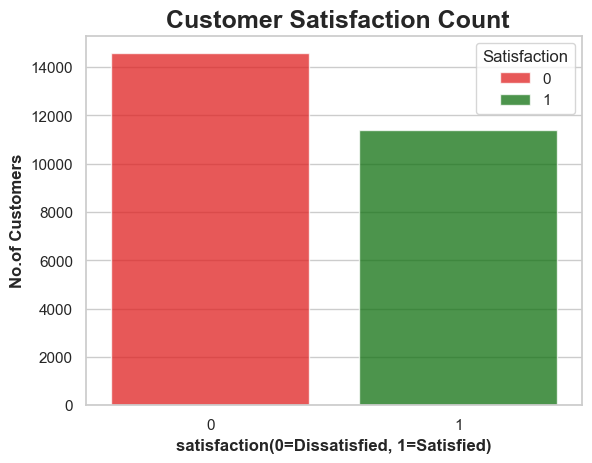

In [2]:
sns.countplot(data=df, x="Satisfaction", hue="Satisfaction", palette=["red", "green"], alpha=0.75)
plt.title(" Customer Satisfaction Count", fontweight="bold", fontsize=18)
plt.xlabel("satisfaction(0=Dissatisfied, 1=Satisfied)", fontweight="bold")
plt.ylabel("No.of Customers", fontweight="bold")
plt.show()

> This indicates large no.of customers are not satisfied with the airline services.

> Hence, Further analysis is required to identify the key factors contributing to customer
dissatisfaction.

## 2. Age distribution

In [ ]:
sns.countplot(data=df, x="Age_group", order=["Teen", "Young", "Mid", "Senior", "Old"], hue="Age_group", palette="Set2")
plt.title("Age Distribution", fontweight="bold", fontsize=18)
plt.xticks(ticks=range(5), labels=["Teen(0-18)", "Young(18-30)", "Mid(30-45)", "Senior(45-60)", "Old(60+)"], fontweight="bold")
plt.yticks(fontweight="bold")
plt.xlabel("Age Group", fontweight="bold")
plt.ylabel("No.of Customers", fontweight="bold")
plt.show()

> This graph shows that middle-aged passengers forms major segment of airline customers.


## 3. Flight Distance Distribution 

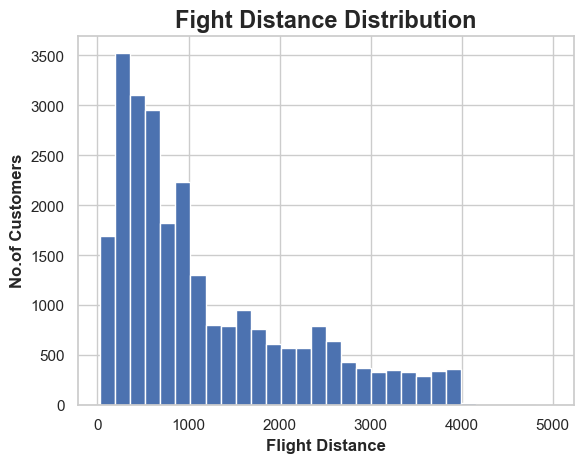

In [4]:
plt.hist(df["Flight Distance"], bins=30)
plt.title("Fight Distance Distribution", fontsize=17, fontweight="bold")
plt.xlabel("Flight Distance", fontweight="bold")
plt.ylabel("No.of Customers", fontweight="bold")
plt.show()

> It is observed that most flights fall within the lower distance range (0–1000 km), indicating that most customers prefer short-distance travel.

> As flight distance increases, the no.of customers decreases significantly, showing that long-distance flights are less common.

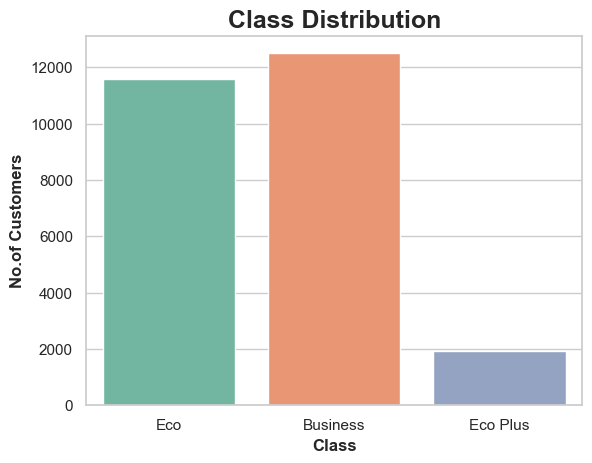

In [5]:
sns.countplot(x="Class", data=df, hue="Class", palette="Set2")
plt.title("Class Distribution", fontsize=18, fontweight="bold")
plt.xlabel("Class", fontweight="bold")
plt.ylabel("No.of Customers", fontweight="bold")
plt.show()

> This graph shows a higher preference for premium travel among customers.

### Overall Analysis

> Although most of the customers are choosing business class, the dissatisfaction level of customers is higher than the satisfaction level. This indicates even premium customers are not fully satisfied.

> Most of the customers fall in the middle age group (30–45), possibly because they have higher expectations regarding services and comfort.

> Additionally, most journeys are short-distance, as customers frequently use flights for small trips, where flight delays or service inefficiencies may have a stronger negative impact on satisfaction level.

# BIVARIATE ANALYSIS

### Class VS Satisfaction

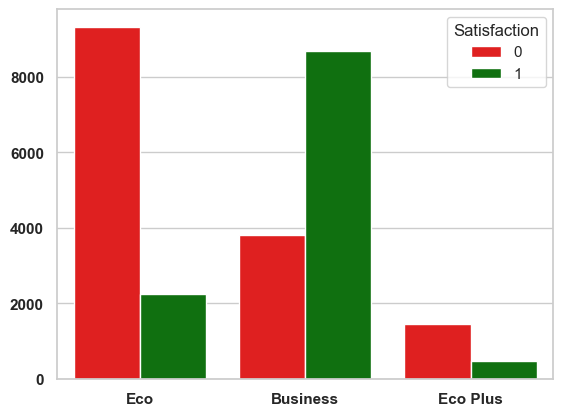

In [6]:
sns.countplot(x="Class", hue="Satisfaction",data=df, palette=["red", "green"], alpha=1)
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.xlabel(None)
plt.ylabel(None)
plt.show()


> The above graph shows that customers travelling in business class have a significantly higher satisfaction rate than dissatisfaction rate.

> In contrast, customers in economy show a higher no.of dissatisfied customers, suggesting that customers in this category are not fully satisfied with the services provided.

> Similarly, Eco Plus also exhibits more dissatisfaction than satisfaction, although the number of customers in this category is relatively lower.

### Overall, this indicates that customer satisfaction is strongly influenced by the travel class, with premium services leading to better customer experiences. Further analysis is needed to understand why economy customers are dissatisfied.

### 1. Inflight wi-fi services

[]

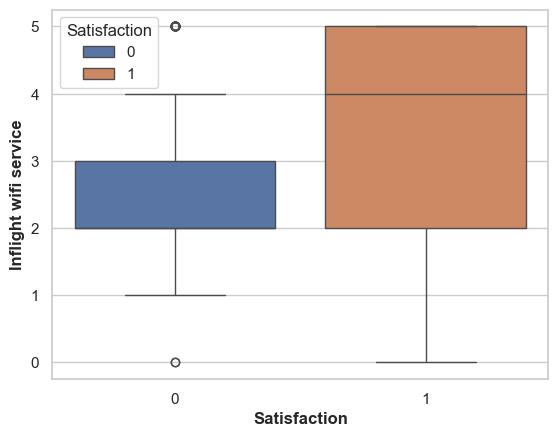

In [7]:
sns.boxplot(x="Satisfaction", y="Inflight wifi service" , data=df, hue="Satisfaction")
plt.xlabel("Satisfaction", fontweight="bold")
plt.ylabel("Inflight wifi service", fontweight="bold")
plt.plot()

> This graph shows that for wifi services dissatisfied people gave ratings around 2-3 and satisfied people gave rating around 4-5

> This indicates that better WiFi service is strongly associated with higher customer satisfaction. Hence, inflight WiFi quality is an important factor influencing customer experience.

### 2. Seat Comfort & Inflight Entertainment

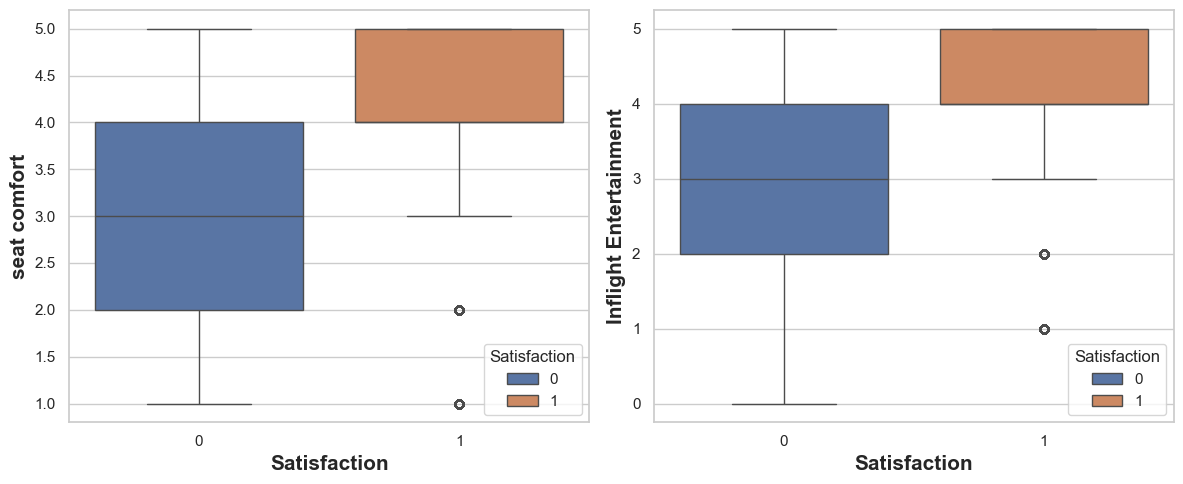

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x="Satisfaction", y="Seat comfort", hue="Satisfaction", data=df)
plt.xlabel("Satisfaction", fontweight="bold", fontsize=15)
plt.ylabel("seat comfort", fontweight="bold", fontsize=15)

plt.subplot(1,2,2)
sns.boxplot(x="Satisfaction", y="Inflight entertainment", data=df, hue="Satisfaction")
plt.xlabel("Satisfaction", fontweight="bold", fontsize=15)
plt.ylabel("Inflight Entertainment", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

> The graphs indicate that overlap occurs between ratings of satisfied and dissatisfied customers. Even dissatisfied customers sometimes give the highest ratings.

> This indicates that seat comfort and inflight entertainment alone are not the sole determining factors. Other services also play a role in influencing overall satisfaction.

### 3. Remaining major factors

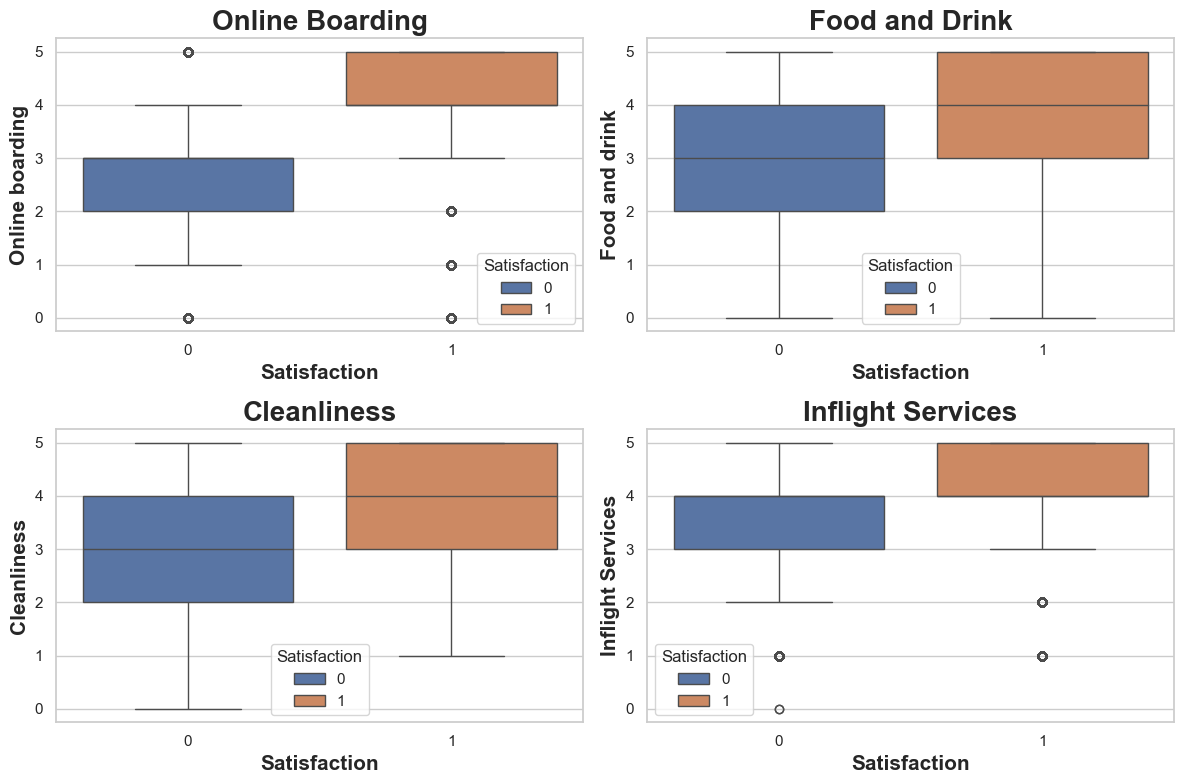

In [9]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
sns.boxplot(x="Satisfaction", y="Online boarding", data=df, hue="Satisfaction")
plt.title("Online Boarding", fontweight='bold', fontsize=20)
plt.xlabel("Satisfaction", fontweight="bold", fontsize=15)
plt.ylabel("Online boarding", fontweight="bold", fontsize=15)

plt.subplot(2,2,2)
sns.boxplot(x="Satisfaction", y="Food and drink", data=df, hue="Satisfaction")
plt.title("Food and Drink", fontweight='bold', fontsize=20)
plt.xlabel("Satisfaction", fontweight="bold", fontsize=15)
plt.ylabel("Food and drink", fontweight="bold", fontsize=15)

plt.subplot(2,2,3)
sns.boxplot(x="Satisfaction", y="Cleanliness", data=df, hue="Satisfaction")
plt.title("Cleanliness", fontweight='bold', fontsize=20)
plt.xlabel("Satisfaction", fontweight="bold", fontsize=15)
plt.ylabel("Cleanliness", fontweight="bold", fontsize=15)

plt.subplot(2,2,4)
sns.boxplot(x="Satisfaction", y="Inflight service", data=df, hue="Satisfaction")
plt.title("Inflight Services", fontweight='bold', fontsize=20)
plt.xlabel("Satisfaction", fontweight="bold", fontsize=15)
plt.ylabel("Inflight Services", fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

> The comparative box plots show that online boarding has a strong influence on customer satisfaction, as there is a clear difference in ratings between satisfied and dissatisfied customers.

> Food & drink and cleanliness show moderate influence, as there is some overlap between the ratings of satisfied and dissatisfied customers, indicating that these factors contribute to satisfaction but are not the sole determinants.

> In contrast, inflight services show minimal variation between the two groups, suggesting that this feature has a weaker impact on overall satisfaction.

> Overall, the analysis indicates that operational efficiency (such as online boarding) plays a more significant role in customer satisfaction compared to general service quality factors.

# MULTI-VARIATE ANALYSIS

## 1. Heat Map

In [ ]:
corr= df.select_dtypes(include=('int64', 'float64')).corr()
corr_target=corr[['Satisfaction']].sort_values(by='Satisfaction',ascending=False)
plt.figure(figsize=(6,10))
sns.heatmap(corr_target, annot=True, cmap="coolwarm",fmt=".1f", linewidths=0.5)
plt.show()

> This graph shows that no feature has a correlation in the range of 0.7–0.8, i.e., satisfaction is not dependent on a single factor; it is a combination of multiple factors, with operational efficiency (Online Boarding) playing the crucial role.

## TOP 3 REASONS FOR DISSATISFACTION
> 1. Online Boarding

> 2. Inflight Entertainment

> 3. Seat/ Food/ Cleanliness/ WI-FI (Tie)


#### Although WiFi service appeared to have a strong effect in the boxplot, the correlation value is moderate because even satisfied customers sometimes gave lower ratings. This reduces the overall strength of the relationship.

#### In contrast, Online Boarding shows a clearer distinction where satisfied customers consistently give higher ratings and dissatisfied customers gave lower ratings. This consistent pattern results in a higher correlation value for online boarding.